#### 1) Setup & Data Loading

* Importe the Palmer's Penguins dataset from Kaggle

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
penguins = pd.read_csv(url)
print(penguins.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  


**Q1** (check): How many rows and columns does the dataset have? Which columns are numeric vs categorical?

In [5]:
print(penguins.shape)
penguins.dtypes

(344, 7)


species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

#### 2) Basic EDA (Exploratory Data Analysis)

In [6]:
#Your code here

**Q2**: Which columns contain missing values? What strategy will you use to handle them?

In [17]:
df_missing = (
    penguins.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_count"})
)

print(df_missing)

              column  missing_count
0            species              0
1             island              0
2     bill_length_mm              2
3      bill_depth_mm              2
4  flipper_length_mm              2
5        body_mass_g              2
6                sex             11


**Q3**: Is the dataset balanced across the three species?

#### 3) Data Cleaning & Encoding

* We’ll keep only rows with complete values for simplicity.

In [19]:
penguins_complete = penguins.dropna()
print(penguins_complete.head())

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
4  Adelie  Torgersen            36.7           19.3              193.0   
5  Adelie  Torgersen            39.3           20.6              190.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
4       3450.0  FEMALE  
5       3650.0    MALE  


**Q4**: Why don’t we need to scale features for Decision Trees?

In [20]:
penguins_encoded = pd.get_dummies(penguins, columns=["island", "sex"], drop_first=True)

penguins_encoded.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_MALE
0,Adelie,39.1,18.7,181.0,3750.0,False,True,True
1,Adelie,39.5,17.4,186.0,3800.0,False,True,False
2,Adelie,40.3,18.0,195.0,3250.0,False,True,False
3,Adelie,NaN,NaN,NaN,NaN,False,True,False
4,Adelie,36.7,19.3,193.0,3450.0,False,True,False


#### 4) Train/Test Split

In [23]:
from sklearn.model_selection import train_test_split

# Define x and y
X = penguins_encoded.drop("species", axis=1)  # features
y = penguins_encoded["species"]               # target

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train dimension :", X_train.shape)
print("Test dimension  :", X_test.shape)

Train dimension : (275, 7)
Test dimension  : (69, 7)


**Q5**: Why do we use stratify=y in this split?

#### 5) Baseline Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Set the model
dtree = DecisionTreeClassifier(random_state=42)

# Train
dtree.fit(X_train, y_train)

# Prediction
y_pred = dtree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69


Confusion Matrix:
 [[30  0  0]
 [ 0 14  0]
 [ 0  0 25]]


**Q6**: Which classes are the most/least confounded? What might cause that?

#### 6) Visualize the Tree

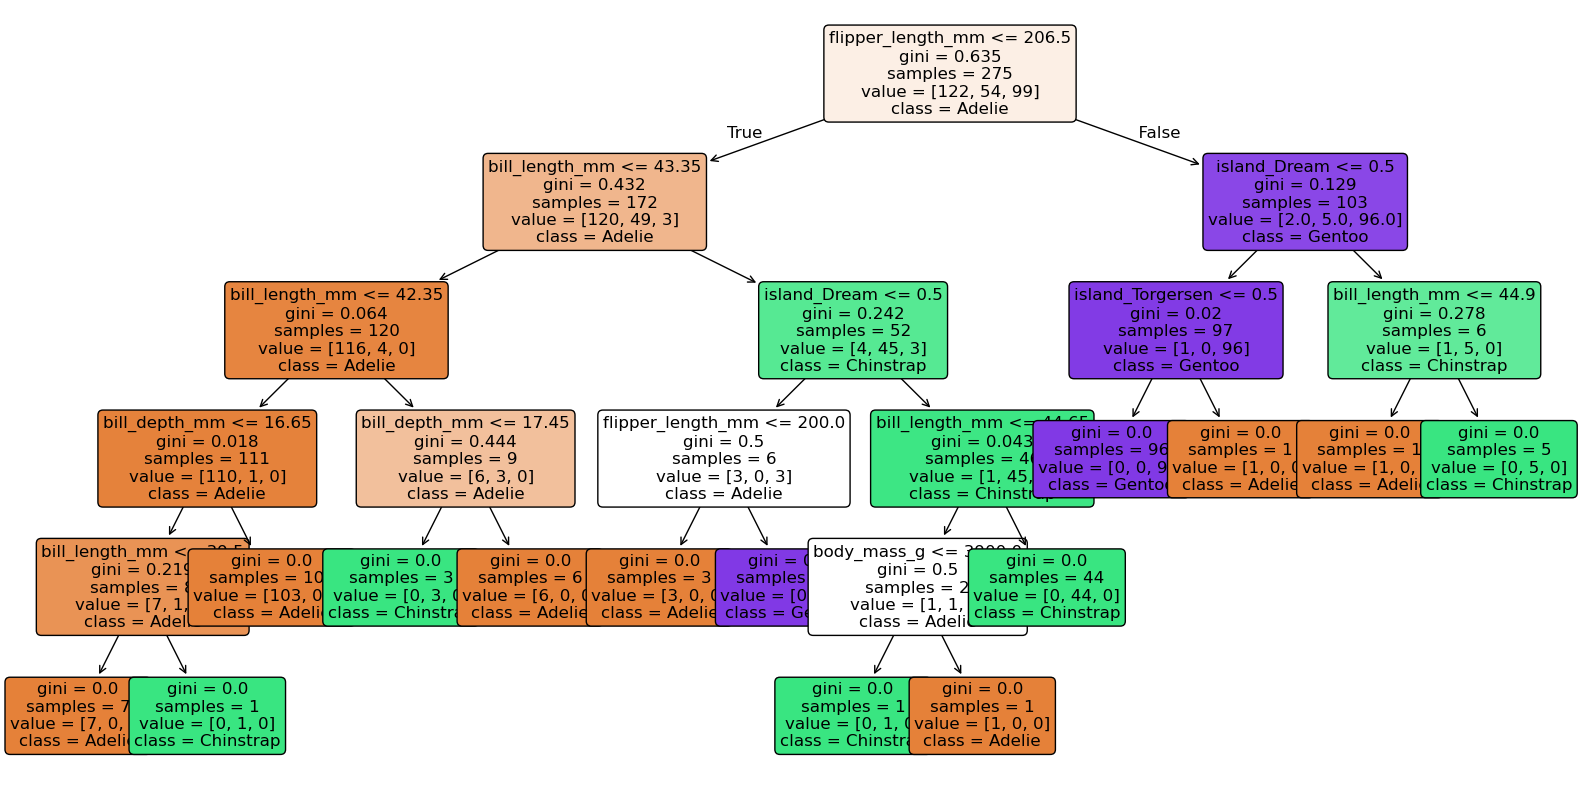

In [25]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    dtree, 
    feature_names=X_train.columns, 
    class_names=dtree.classes_, 
    filled=True,     
    rounded=True,       
    fontsize=12
)

plt.show()


**Q7**: What is the root split (feature and threshold)? Why do you think the algorithm chose it?

#### 7) Decision Boundaries (2D View)
* Pick two features (e.g., bill_length_mm vs bill_depth_mm) and visualize the decision surface.

c:\Users\aurel\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\Users\aurel\anaconda3\Lib\site-packages\matplotlib\colors.py:1353: UserWarning: Warning: converting a masked element to nan.
  dtype = np.min_scalar_type(value)
c:\Users\aurel\anaconda3\Lib\site-packages\matplotlib\colors.py:1360: UserWarning: Warning: converting a masked element to nan.
  data = np.asarray(value)
c:\Users\aurel\anaconda3\Lib\site-packages\matplotlib\ticker.py:547: UserWarning: Warning: converting a masked element to nan.
  else fmt % arg)


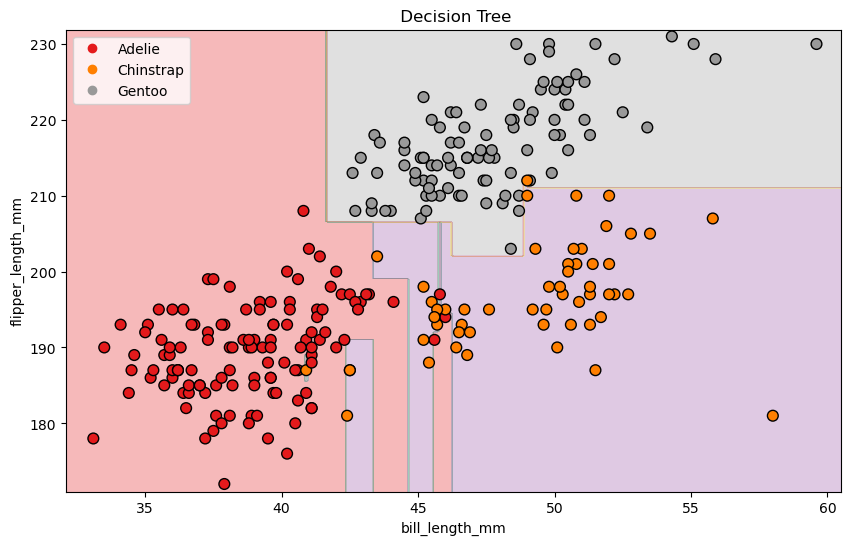

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

features = ["bill_length_mm", "flipper_length_mm"]
X_2d = X_train[features]
y_2d = y_train

le = LabelEncoder()
y_encoded = le.fit_transform(y_2d)

dtree_2d = DecisionTreeClassifier(random_state=42)
dtree_2d.fit(X_2d, y_encoded)

x_min, x_max = X_2d[features[0]].min() - 1, X_2d[features[0]].max() + 1
y_min, y_max = X_2d[features[1]].min() - 1, X_2d[features[1]].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = dtree_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')

# Scatter points
scatter = plt.scatter(
    X_2d[features[0]], 
    X_2d[features[1]], 
    c=y_encoded, 
    cmap='Set1', 
    edgecolor='k',
    s=60
)

# ---- FIX de la légende ----
handles, _ = scatter.legend_elements()
labels = list(le.classes_)  
plt.legend(handles, labels)

plt.xlabel(features[0])
plt.ylabel(features[1])
plt.title(" Decision Tree")
plt.show()


**Q8**: Do the boundaries look axis-aligned? Why is that a natural property of Decision Trees?

#### 8) Hyperparameter Tuning with GridSearchCV

In [34]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 6, 8],
    "max_features": [None, "sqrt", "log2"]
}

# Modèle de base
dt = DecisionTreeClassifier(random_state=42)

# Grid Search avec cross-validation
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,              # 5-fold CV
    n_jobs=-1,         # parallélisation
    scoring="accuracy",
    verbose=1
)

# Entraînement sur les features encodées
grid_search.fit(X_train, y_train)

# Résultats
print("Best parameters:", grid_search.best_params_)
print("Best cross-val accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 1440 candidates, totalling 7200 fits
Best parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best cross-val accuracy: 0.9745454545454546


In [35]:
best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))


Test accuracy: 0.9710144927536232

Classification report:
               precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        30
   Chinstrap       1.00      0.93      0.96        14
      Gentoo       0.96      1.00      0.98        25

    accuracy                           0.97        69
   macro avg       0.98      0.97      0.97        69
weighted avg       0.97      0.97      0.97        69



**Q9**: Which hyperparameters changed compared to the baseline? How did test accuracy change?

**Q10**: If CV accuracy is much higher than test accuracy, what could be happening?

#### 9) Model Interpretation

In [36]:
import pandas as pd

importances = pd.Series(best_dt.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)


flipper_length_mm    0.530758
bill_length_mm       0.313258
bill_depth_mm        0.094691
island_Dream         0.061292
body_mass_g          0.000000
island_Torgersen     0.000000
sex_MALE             0.000000
dtype: float64

In [38]:
from sklearn.tree import export_text
print(export_text(best_dt, feature_names=list(X_train.columns)))

|--- flipper_length_mm <= 206.50
|   |--- bill_length_mm <= 43.35
|   |   |--- bill_length_mm <= 42.35
|   |   |   |--- bill_depth_mm <= 16.65
|   |   |   |   |--- class: Adelie
|   |   |   |--- bill_depth_mm >  16.65
|   |   |   |   |--- class: Adelie
|   |   |--- bill_length_mm >  42.35
|   |   |   |--- class: Adelie
|   |--- bill_length_mm >  43.35
|   |   |--- island_Dream <= 0.50
|   |   |   |--- class: Adelie
|   |   |--- island_Dream >  0.50
|   |   |   |--- bill_length_mm <= 44.65
|   |   |   |   |--- class: Adelie
|   |   |   |--- bill_length_mm >  44.65
|   |   |   |   |--- class: Chinstrap
|--- flipper_length_mm >  206.50
|   |--- bill_depth_mm <= 18.00
|   |   |--- class: Gentoo
|   |--- bill_depth_mm >  18.00
|   |   |--- class: Chinstrap



**Q11**: Which feature is most important? Is that consistent with your EDA intuition?

**Q12**: For the inspected sample, does the class probability look confident? Why/why not?

#### 10) (Optional) Add Categorical Features & Compare

In [16]:
#Your code here

**Q13**: Did adding island/sex help? Why might these variables be informative for species?

#### 11) Reflection & Reporting

Write a short reflection (5–10 lines):
- Compare Decision Tree vs KNN on this dataset.
-  Where does the tree overfit? How did pruning/tuning impact generalization?
- Which 2D feature pair gave the clearest separation? Why?